In [47]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
import matplotlib.pyplot as plt
import pickle, os, sys
import jax
import jax.numpy as jnp 
from jax import random

from xpinn_regression import load_data, initialize_xpinn, initialize_loss
from xpinn_regression import DataOutput, XPINNOutput, LossOutput

In [ ]:
TEST_FOLDER = os.getcwd()
TEST_NAME = 'flatbed'
USE_EQN = True
USE_CT = True
USE_MATCHING = True

OPTIMIZER = 'KFAC'

LOAD_STEP = 62000

CKPT_PATH = os.path.join(TEST_FOLDER, f'match_ct_eqn_{TEST_NAME}_checkpoints_MATCHGRADMU')
# CKPT_PATH = os.path.join(TEST_FOLDER, 'floating_region1_only_ct_eqn_flatbed_checkpoints')
# CKPT_PATH = os.path.join(TEST_FOLDER, 'grounded_region0_from_floating_match_eqn_flatbed_checkpoints')
# CKPT_PATH = os.path.join(TEST_FOLDER, f'grounded_only_interface_mu_ct_{'match_' if USE_MATCHING else ''}{'ct_' if USE_CT else ''}{'eqn_' if USE_EQN else ''}{TEST_NAME}_checkpoints')

In [50]:
print(TEST_FOLDER)
print(f'Loading Checkpoint from', CKPT_PATH)

/Users/jasperchen/Academics/Software/diffice/DIFFICE_jax/tests/test_xpinn_regression
Loading Checkpoint from /Users/jasperchen/Academics/Software/diffice/DIFFICE_jax/tests/test_xpinn_regression/match_ct_eqn_flatbed_checkpoints_SUCCESS1


In [51]:
# plt.semilogy(loss_history, 'k-')
# plt.grid(which='both', ls='--')

In [52]:
class _MissingKfac:
    def __init__(self, *args, **kwargs):
        pass

class NoKfacUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("kfac_jax"):
            return _MissingKfac
        return super().find_class(module, name)

prefix = "KFAC_" if OPTIMIZER=="KFAC" else ""
ckpt_file = os.path.join(CKPT_PATH, f"{prefix}step_{LOAD_STEP}.pkl")

with open(ckpt_file, "rb") as f:
    state = NoKfacUnpickler(f).load()

params = state["params"]

In [53]:
state.keys()

dict_keys(['step', 'params', 'opt_state', 'damping', 'loss_history', 'freeze_spec', 'region_term_weights'])

In [54]:
keys = random.PRNGKey(8132002)
data, dense_data = load_data(os.path.join(TEST_FOLDER, f'{TEST_NAME}_data_xpinns_regression_test.mat'), load_extra=True)
scale = data.scale 

_, xpinn = initialize_xpinn(keys, data)
sol_NN = xpinn.sol_NN 
net = sol_NN[0]
eqn = xpinn.eval_f
idxgall = data.idxgall

[2] Loading and normalizing data from: /Users/jasperchen/Academics/Software/diffice/DIFFICE_jax/tests/test_xpinn_regression/flatbed_data_xpinns_regression_test.mat


 . . . basal_mask (all regions): [True, False]
[0, 1]
None
[{'net_u': {'depth': 6, 'width': 30}, 'net_mu': {'depth': 6, 'width': 30}, 'net_c0': {'depth': 6, 'width': 30}, 'net_c1': {'depth': 6, 'width': 30}}, {'net_u': {'depth': 6, 'width': 30}, 'net_mu': {'depth': 6, 'width': 30}, 'net_c0': {'depth': 6, 'width': 30}, 'net_c1': {'depth': 6, 'width': 30}}]
2


In [55]:
data_raw_region = []
data_norm_region = []
for i in range(len(idxgall)):
    data_raw_sub = data.data_all[i][4][3]
    data_norm_sub = data.data_all[i][4][2]
    data_raw_region.append(data_raw_sub)
    data_norm_region.append(data_norm_sub)

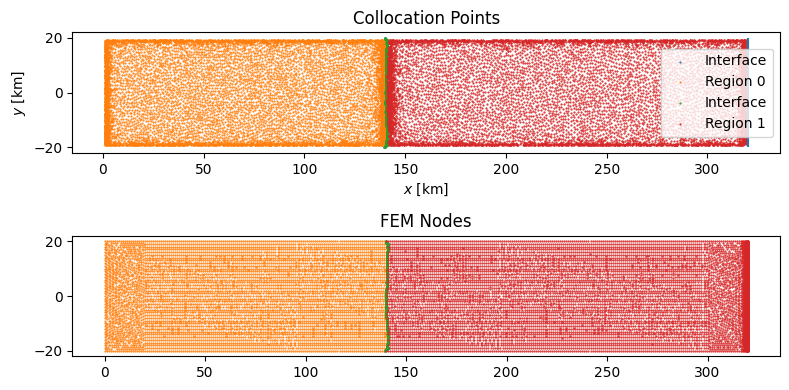

In [56]:
fig, axs = plt.subplots(2, 1, figsize=(8, 4))
for i in range(len(idxgall)):
    x_fem, y_fem = data_raw_region[i][0]/1e3, data_raw_region[i][1]/1e3 
    x_col, y_col = data_raw_region[i][8]/1e3, data_raw_region[i][9]/1e3
    if i < len(idxgall):
        x_md, y_md = data_raw_region[i][10]/1e3, data_raw_region[i][11]/1e3
        axs[0].scatter(x_md, y_md, 0.3, label='Interface')
        axs[1].scatter(x_md, y_md, 0.3)
    axs[0].scatter(x_col, y_col, 0.3, label=f'Region {i}')
    axs[1].scatter(x_fem, y_fem, 0.3, label=f'Region {i}')
# axs[0].set_xlim(-1, 3)
axs[0].vlines(320, ymin=-20, ymax=20)
# for i in range(2):
#     axs[i].set_xlim(200, 220)
axs[0].legend()
axs[0].set_xlabel('$x$ [km]')
axs[0].set_ylabel('$y$ [km]')
axs[0].set_title('Collocation Points')
axs[1].set_title('FEM Nodes')
plt.tight_layout()

In [57]:
net_predictions = []
eqn_evals = []
x_raw = []
y_raw = []
xh_raw = []
yh_raw = []
xcol_norm = []
ycol_norm = []
xcol_raw = []
ycol_raw = []

eval_points_raw = []
eval_points_norm = []

for i in range(len(idxgall)):
    x_raw_region = data_raw_region[i][0]/1e3 
    y_raw_region = data_raw_region[i][1]/1e3
    
    xh_raw_region = data_raw_region[i][4]/1e3 
    yh_raw_region = data_raw_region[i][5]/1e3
    
    x_norm = data_norm_region[i][0]
    y_norm = data_norm_region[i][1]
    
    xcol_raw_region = data_raw_region[i][8]
    ycol_raw_region = data_raw_region[i][9]
    
    xcol_norm_region = data_norm_region[i][8]
    ycol_norm_region = data_norm_region[i][9]

    eval_x_arr_raw = jnp.linspace(jnp.min(x_raw_region), jnp.max(x_raw_region), 150)
    eval_y_arr_raw = jnp.linspace(jnp.min(y_raw_region), jnp.max(y_raw_region), 50)
    
    eval_x_arr_norm = jnp.linspace(jnp.min(x_norm), jnp.max(x_norm), 150)
    eval_y_arr_norm = jnp.linspace(jnp.min(y_norm), jnp.max(y_norm), 50)

    x_grid, y_grid = jnp.meshgrid(eval_x_arr_raw, eval_y_arr_raw)
    x_grid = jnp.expand_dims(x_grid.flatten(), 1)
    y_grid = jnp.expand_dims(y_grid.flatten(), 1)
    
    x_grid_norm, y_grid_norm = jnp.meshgrid(eval_x_arr_norm, eval_y_arr_norm)
    x_grid_norm = jnp.expand_dims(x_grid_norm.flatten(), 1)
    y_grid_norm = jnp.expand_dims(y_grid_norm.flatten(), 1)
    
    
    
    print('xcol_raw shape = ', xcol_raw_region.shape) 
    print('ycol_raw shape = ', ycol_raw_region.shape) 
    
    print('xcol_norm shape = ', xcol_norm_region.shape) 
    print('ycol_norm shape = ', ycol_norm_region.shape) 
    
    x_raw.append(x_raw_region)
    y_raw.append(y_raw_region)
    xh_raw.append(xh_raw_region)
    yh_raw.append(yh_raw_region)
    
    xcol_raw.append(xcol_raw_region)
    ycol_raw.append(ycol_raw_region)
    
    xcol_norm.append(xcol_norm_region)
    ycol_norm.append(ycol_norm_region)
    
    eval_points_raw.append(jnp.hstack((x_grid, y_grid)))
    eval_points_norm.append(jnp.hstack((x_grid_norm, y_grid_norm)))
    
    net_predictions.append(jax.vmap(lambda z: net(params, z, i), in_axes=(0,))(eval_points_norm[-1]))
    eqn_evals.append(eqn(params, jnp.hstack((x_grid_norm, y_grid_norm)), i))
    # eqn_evals.append(eqn(params, jnp.hstack((x_norm, y_norm)), i))
    print(eqn_evals[-1][1].shape)

xcol_raw shape =  (8000,)
ycol_raw shape =  (8000,)
xcol_norm shape =  (8000, 1)
ycol_norm shape =  (8000, 1)
(7500, 9)
xcol_raw shape =  (8000,)
ycol_raw shape =  (8000,)
xcol_norm shape =  (8000, 1)
ycol_norm shape =  (8000, 1)
(7500, 7)


In [58]:
# interpolate data 
from scipy.interpolate import griddata 
x_eval = []
y_eval = []
u_eval = []
v_eval = []
h_eval = []
s_eval = []
mu_eval = []
C_eval = []
h_sparse = []
s_sparse = []
YTS = 365 * 24 * 3600
for i in range(len(idxgall)):
    x_raw_region = x_raw[i][:,None]
    y_raw_region = y_raw[i][:,None]

    print('x_raw_region shape', x_raw_region.shape)
    print('x_raw_region shape', y_raw_region.shape)
    xh_raw_region = xh_raw[i][:,None] 
    yh_raw_region = yh_raw[i][:,None]
    u_raw_region = data_raw_region[i][2] * YTS 
    print('u_raw_region shape', u_raw_region.shape)
    v_raw_region = data_raw_region[i][3] * YTS 
    h_sparse_region = data_raw_region[i][6][:,None]
    h_raw_region = dense_data['h_dense'][0, i].reshape(-1)
    print('h_raw_region shape', h_raw_region.shape)
    s_sparse_region = data_raw_region[i][7][:,None]
    s_raw_region = dense_data['s_dense'][0,i].reshape(-1)
    mu_raw_region = data_raw_region[i][12]
    C_raw_region = data_raw_region[i][13]

    x_eval_region = eval_points_raw[i][:,0]
    y_eval_region = eval_points_raw[i][:,1]

    u_eval_region = griddata(jnp.hstack((x_raw_region, y_raw_region)), u_raw_region, eval_points_raw[i])
    v_eval_region = griddata(jnp.hstack((x_raw_region, y_raw_region)), v_raw_region, eval_points_raw[i])
    h_eval_region = griddata(jnp.hstack((x_raw_region, y_raw_region)), h_raw_region, eval_points_raw[i])
    s_eval_region = griddata(jnp.hstack((x_raw_region, y_raw_region)), s_raw_region, eval_points_raw[i])
    mu_eval_region = griddata(jnp.hstack((x_raw_region, y_raw_region)), mu_raw_region, eval_points_raw[i])
    C_eval_region = griddata(jnp.hstack((x_raw_region, y_raw_region)), C_raw_region, eval_points_raw[i])

    x_eval.append(x_eval_region)
    y_eval.append(y_eval_region)
    u_eval.append(u_eval_region)
    v_eval.append(v_eval_region)
    h_eval.append(h_eval_region)
    s_eval.append(s_eval_region)
    mu_eval.append(mu_eval_region)
    C_eval.append(C_eval_region)
    h_sparse.append(h_sparse_region)
    s_sparse.append(s_sparse_region)
    

x_raw_region shape (6226, 1)
x_raw_region shape (6226, 1)
u_raw_region shape (6226,)
h_raw_region shape (6226,)
x_raw_region shape (9962, 1)
x_raw_region shape (9962, 1)
u_raw_region shape (9962,)
h_raw_region shape (9962,)


In [59]:
v_eval[1]

array([0., 0., 0., ..., 0., 0., 0.], shape=(7500,))

(7500,)
[DEBUG]: Maximum elv. in region 0 = 719.19482421875
[DEBUG]: Minimum elv. in region 0 = 144.99822998046875
region 0: abs. rel. err. u = 0.30%
region 0: abs. rel. err. v = 0.35%
(7500,)
[DEBUG]: Maximum elv. in region 1 = 144.45269775390625
[DEBUG]: Minimum elv. in region 1 = 30.823902130126953
region 1: abs. rel. err. u = 0.15%
region 1: abs. rel. err. v = 0.19%


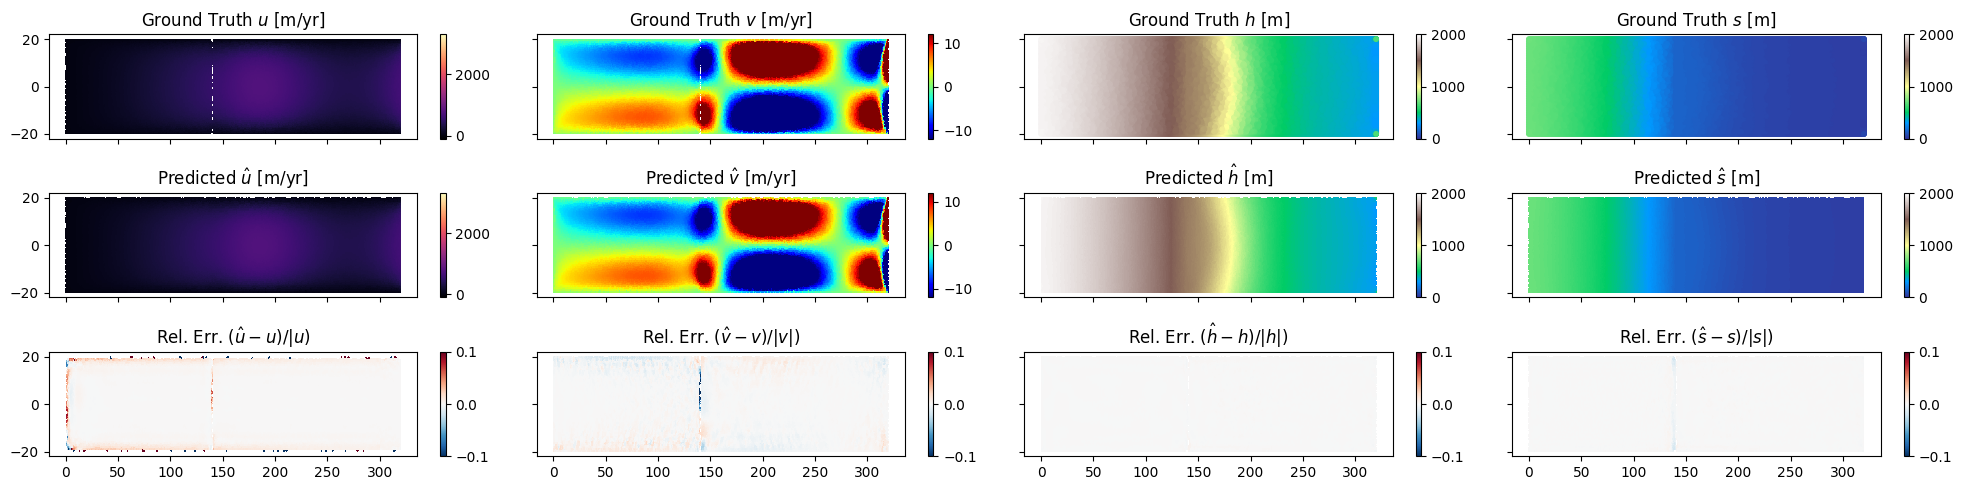

In [60]:
fig, axs = plt.subplots(3, 4, figsize=(20, 5), sharex=True, sharey=True)

u_misfit = [] 
v_misfit = []

ERR_SCALE = 0.1
for i in range(len(idxgall)):
    x_eval_region = x_eval[i]
    y_eval_region = y_eval[i]
    u_eval_region = u_eval[i]
    v_eval_region = v_eval[i]
    h_eval_region = h_eval[i]
    s_eval_region = s_eval[i]
    xh_raw_region = xh_raw[i]
    yh_raw_region = yh_raw[i]

    print(x_eval_region.shape)

    print(f'[DEBUG]: Maximum elv. in region {i} = {jnp.max(s_eval_region)}')
    print(f'[DEBUG]: Minimum elv. in region {i} = {jnp.min(s_eval_region)}')

    _, _, u_mean, v_mean, h_mean, s_mean = scale[i][0]
    _, _, u_range, v_range, _, s_range = scale[i][1]
    
    pred = net_predictions[i]
    u_pred = (pred[:, 0] * u_range + u_mean) * YTS
    v_pred = (pred[:, 1] * v_range + v_mean) *YTS 
    h_pred = pred[:, 2] * h_mean 
    s_pred = pred[:, 3] * s_range + s_mean

    rel_err_u = (u_pred - u_eval_region) / jnp.abs(u_eval_region)
    rel_err_v = (v_pred - v_eval_region) / (2 * jnp.nanstd(v_eval_region))
    print(f'region {i}: abs. rel. err. u = {jnp.nanmean(jnp.abs(rel_err_u[u_eval_region>5]))*100:.2f}%')
    print(f'region {i}: abs. rel. err. v = {jnp.nanmean(jnp.abs(rel_err_v))*100:.2f}%')
    if len(h_pred) == len(h_eval_region):
        rel_err_h = (h_pred - h_eval_region) / jnp.abs(h_eval_region)
        rel_err_s = (s_pred - s_eval_region) / jnp.abs(s_eval_region)

    row=0
    c00=axs[row, 0].tripcolor(x_eval_region, y_eval_region, u_eval_region, vmin=-100, vmax=3300, cmap='magma')
    c01=axs[row, 1].tripcolor(x_eval_region, y_eval_region, v_eval_region, vmin=-12, vmax=12, cmap='jet')
    # c02=axs[row, 2].tripcolor(x_eval_region, y_eval_region, h_eval_region, vmin=0, vmax=2000, cmap='terrain')
    # c03=axs[row, 3].tripcolor(x_eval_region, y_eval_region, s_eval_region, vmin=0, vmax=2000, cmap='terrain')
    c02=axs[row, 2].scatter(xh_raw_region, yh_raw_region, 10, h_sparse[i], vmin=0, vmax=2000, cmap='terrain')
    c03=axs[row, 3].scatter(xh_raw_region, yh_raw_region, 10, s_sparse[i], vmin=0, vmax=2000, cmap='terrain')

    row=1
    c10=axs[row, 0].tripcolor(x_eval_region, y_eval_region, u_pred, vmin=-100, vmax=3300, cmap='magma')
    c11=axs[row, 1].tripcolor(x_eval_region, y_eval_region, v_pred, vmin=-12, vmax=12, cmap='jet')
    c12=axs[row, 2].tripcolor(x_eval_region, y_eval_region, h_pred, vmin=0, vmax=2000, cmap='terrain')
    c13=axs[row, 3].tripcolor(x_eval_region, y_eval_region, s_pred, vmin=0, vmax=2000, cmap='terrain')

    row=2
    c20=axs[row, 0].tripcolor(x_eval_region, y_eval_region, rel_err_u, vmin=-ERR_SCALE, vmax=ERR_SCALE, cmap='RdBu_r')
    c21=axs[row, 1].tripcolor(x_eval_region, y_eval_region, rel_err_v, vmin=-ERR_SCALE, vmax=ERR_SCALE, cmap='RdBu_r')
    if len(h_pred) == len(h_eval_region):
        c22=axs[row, 2].tripcolor(x_eval_region, y_eval_region, rel_err_h, vmin=-ERR_SCALE, vmax=ERR_SCALE, cmap='RdBu_r')
        c23=axs[row, 3].tripcolor(x_eval_region, y_eval_region, rel_err_s, vmin=-ERR_SCALE, vmax=ERR_SCALE, cmap='RdBu_r')

titles = [
    ['Ground Truth $u$ [m/yr]', 'Ground Truth $v$ [m/yr]', 'Ground Truth $h$ [m]', 'Ground Truth $s$ [m]'],
    [ 'Predicted $\\hat u$ [m/yr]', 'Predicted $\\hat v$ [m/yr]', 'Predicted $\\hat h$ [m]', 'Predicted $\\hat s$ [m]'],
    ['Rel. Err. $(\\hat u - u) / |u)$', 'Rel. Err. $(\\hat v - v) / |v|)$',  'Rel. Err. $(\\hat h - h) / |h|)$', 'Rel. Err. $(\\hat s - s) / |s|)$',]
]
plots = [
    [c00, c01, c02, c03],
    [c10, c11, c12, c13],
    [c20, c21, c22, c23]
]
for i in range(len(titles)):
    for j in range(len(titles[0])):
        axs[i, j].set_title(titles[i][j])
        plt.colorbar(plots[i][j])

plt.tight_layout()

region 0: visc scale = 3.26e+15 Pa s
Region 0, abs mean rel err mu =9.73%
Region 0, abs median rel err C =1.30%
region 1: visc scale = 8.95e+14 Pa s
Region 1, abs mean rel err mu =0.15%
Region 1, abs median rel err C =0.00%


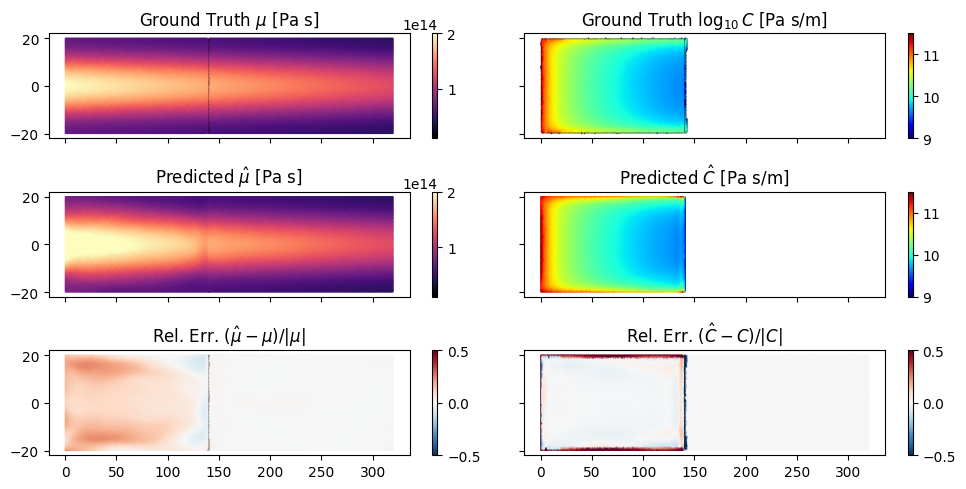

In [61]:
fig, axs = plt.subplots(3, 2, figsize=(10, 5), sharex=True, sharey=True)
YTS = 365 * 24 * 3600
MU_ERR_SCALE = 0.5 
for i in range(len(idxgall)):
    x_eval_region = x_eval[i]
    y_eval_region = y_eval[i]
    mu_eval_region = mu_eval[i]
    C_eval_region = C_eval[i]
    _, _, u_mean, v_mean, h_mean, s_mean = scale[i][0]
    _, _, u_range, v_range, _, s_range = scale[i][1]
    _, _, mu0, c0, _, gamma_mu, gamma_c, _, _, _ = scale[i][2]
    
    print(f'region {i}: visc scale = {mu0:.2e} Pa s')

    pred = net_predictions[i]
    mu_pred = pred[:, 4:5] * mu0 
    if data.basal_mask[i]:
        C_pred = (pred[:, 5:6]) * c0
    else:
        C_pred = jnp.zeros_like(mu_pred)

    rel_err_mu = (mu_pred - mu_eval_region) / jnp.abs(mu_eval_region)
    rel_err_C = (C_pred - C_eval_region) / jnp.abs(C_eval_region + 1e-10)

    # Flatten arrays for tripcolor (requires 1D inputs)
    x = jnp.array(x_eval_region).flatten()
    y = jnp.array(y_eval_region).flatten()

    row = 0
    c00 = axs[row, 0].tripcolor(x, y, jnp.array(mu_eval_region).flatten(), vmin=1e13, vmax=2e14, cmap='magma', shading='gouraud')
    c01 = axs[row, 1].tripcolor(x, y, jnp.array(jnp.log10(C_eval_region)).flatten(), vmin=9, vmax=11.5, cmap='jet', shading='gouraud')
    row = 1
    c10 = axs[row, 0].tripcolor(x, y, jnp.array(mu_pred).flatten(), vmin=1e13, vmax=2e14, cmap='magma', shading='gouraud')
    c11 = axs[row, 1].tripcolor(x, y, jnp.array(jnp.log10(C_pred)).flatten(), vmin=9, vmax=11.5, cmap='jet', shading='gouraud')
    row = 2
    c20 = axs[row, 0].tripcolor(x, y, jnp.array(rel_err_mu).flatten(), vmin=-MU_ERR_SCALE, vmax=MU_ERR_SCALE, cmap='RdBu_r', shading='gouraud')
    c21 = axs[row, 1].tripcolor(x, y, jnp.array(rel_err_C).flatten(), vmin=-MU_ERR_SCALE, vmax=MU_ERR_SCALE, cmap='RdBu_r', shading='gouraud')

    print(f'Region {i}, abs mean rel err mu ={jnp.nanmedian(jnp.abs(rel_err_mu))*100:.2f}%')
    print(f'Region {i}, abs median rel err C ={jnp.nanmedian(jnp.abs(rel_err_C))*100:.2f}%')

titles = [
    ['Ground Truth $\\mu$ [Pa s]', 'Ground Truth $\\log_{10}C$ [Pa s/m]'],
    ['Predicted $\\hat \\mu$ [Pa s]', 'Predicted $\\hat C$ [Pa s/m]'],
    [f'Rel. Err. $(\\hat \\mu - \\mu) / |\\mu|$', f'Rel. Err. $(\\hat C - C) / |C|$']
]
plots = [
    [c00, c01],
    [c10, c11],
    [c20, c21]
]
for i in range(len(titles)):
    for j in range(len(titles[0])):
        axs[i, j].set_title(titles[i][j])
        plt.colorbar(plots[i][j])

plt.tight_layout()

In [62]:
jnp.max(rel_err_C)

Array(0., dtype=float32)

gamma_c = 0.5
f shape (7500, 2)
terms shape (7500, 9)
SIGMA_G = 262442.34375
(7500,)
(7500, 2)
(7500, 9)
Region 0: mean   rel. x residual =       4.76% of gravitational driving stress (x)
Region 0: median rel. x residual =       0.02% of gravitational driving stress (x)
Region 0: mean   rel. y residual =       5.18% of maximum term in stress balance (y)
Region 0: median rel. y residual =       2.50% of maximum term in stress balance (y)
f shape (7500, 2)
terms shape (7500, 7)
SIGMA_G = 16764.521484375
(7500,)
(7500, 2)
(7500, 7)
Region 1: mean   rel. x residual =       0.79% of gravitational driving stress (x)
Region 1: median rel. x residual =       0.09% of gravitational driving stress (x)
Region 1: mean   rel. y residual =       1.41% of maximum term in stress balance (y)
Region 1: median rel. y residual =       0.52% of maximum term in stress balance (y)


(-2.0, 2.0)

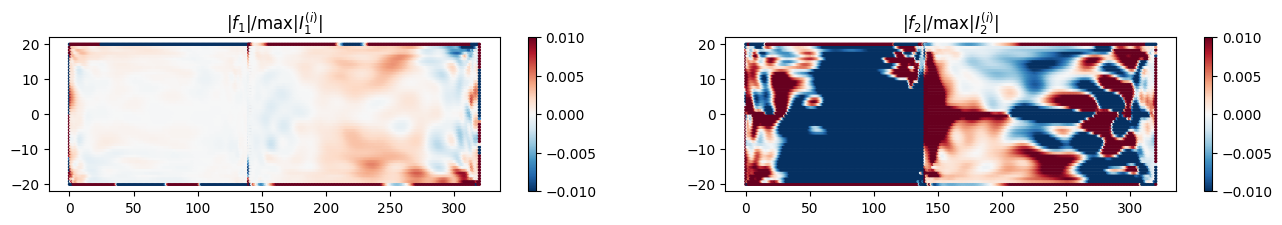

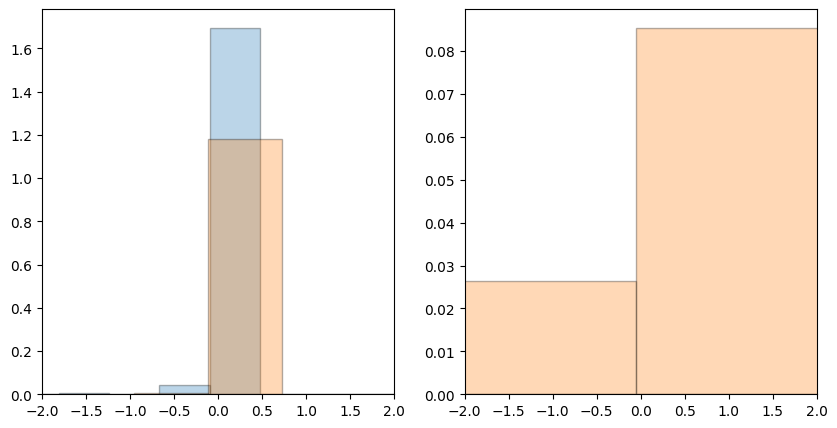

In [63]:
fig, axs = plt.subplots(1, 2, figsize=(16, 2), sharex=True)

ERR_SCALE = 0.01

print(f'gamma_c = {gamma_c}')

y_eqn_term_argmax = []
for i in range(len(idxgall)):
    xcol = x_eval[i] 
    ycol = y_eval[i]
    f, terms = eqn_evals[i]
    print('f shape', f.shape)
    print('terms shape', terms.shape)
    SIGMA_G = scale[i].dynamic_scale.term0
    print(f'SIGMA_G = {SIGMA_G}')
    print(xcol.shape)
    print(f.shape)
    print(terms.shape)

    x_eqn_res = f[:, 0:1]
    y_eqn_res = f[:, 1:2]
        
    x_eqn_normalizer = terms[:, 2:3]/gamma_mu if terms.shape[1]>=8 else jnp.max(jnp.abs(terms[:, 0:3]), axis=1)[:,None] + 1e-10
    x_res_rel = x_eqn_res / x_eqn_normalizer

    if data.basal_mask[i]:
        # y_eqn_normalizer = gamma_c*terms[:, 8:9]/gamma_mu 
        y_eqn_normalizer = jnp.max(jnp.abs(jnp.hstack((terms[:, 3:6], terms[:, 8:9]))), axis=1)[:,None] + 1e-10
        # y_eqn_normalizer *= 30.0 # [NOTE]: Hard-coded scaling for across-flow equation residuals
        y_eqn_normalizer_idx = jnp.argmax(jnp.abs(jnp.hstack((terms[:, 3:6], terms[:, 8:9]))), axis=1)[:,None]
    else:
        y_eqn_normalizer = jnp.max(jnp.abs(terms[:, 3:6]), axis=1)[:,None] + 1e-10
        y_eqn_normalizer_idx = jnp.argmax(jnp.abs(terms[:, 3:6]), axis=1)[:,None] + 1e-10
    y_eqn_term_argmax.append(y_eqn_normalizer_idx)
    y_res_rel = y_eqn_res / 10.0 / y_eqn_normalizer
    # if i == 0:
    #     plt.figure()
    #     # plt.hist(y_eqn_res, bins=jnp.linspace(-0.25, 0.25, 25), alpha=0.5, edgecolor='k')
    #     # plt.hist(y_eqn_normalizer, bins=jnp.linspace(-0.25, 0.25, 25), alpha=0.5, edgecolor='k')
    #     plt.hist(y_res_rel, bins=jnp.linspace(-50, 50, 100))
    #     plt.xlim(-50, 50)
    #     # plt.xlim(-0.25, 0.25)

    print(f'Region {i}: mean   rel. x residual = {jnp.mean(jnp.abs(x_res_rel))*100:10.2f}% of gravitational driving stress (x)')
    print(f'Region {i}: median rel. x residual = {jnp.median(jnp.abs(x_res_rel))*100:10.2f}% of gravitational driving stress (x)')
    print(f'Region {i}: mean   rel. y residual = {jnp.mean(jnp.abs(y_res_rel))*100:10.2f}% of maximum term in stress balance (y)')
    print(f'Region {i}: median rel. y residual = {jnp.median(jnp.abs(y_res_rel))*100:10.2f}% of maximum term in stress balance (y)')
    eqnx=axs[0].scatter(xcol, ycol, 2, x_res_rel, vmin=-ERR_SCALE, vmax=ERR_SCALE, cmap='RdBu_r')
    eqny=axs[1].scatter(xcol, ycol, 2, y_res_rel, vmin=-ERR_SCALE, vmax=ERR_SCALE, cmap='RdBu_r')

axs[0].set_title('$|f_1|/\\max|I_1^{(i)}|$')
axs[1].set_title('$|f_2|/\\max|I_2^{(i)}|$')
plt.colorbar(eqnx)
plt.colorbar(eqny)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for i in range(len(idxgall)):
    f, terms = eqn_evals[i]
    x_eqn_normalizer = terms[:, 2:3]/gamma_mu if terms.shape[1]>=8 else terms[:, 2:3]
    y_eqn_normalizer = gamma_c*terms[:, 8:9]/gamma_mu if terms.shape[1] >= 8 else terms[:, 3:4] 
    x_res_rel = f[:, 0:1] / x_eqn_normalizer
    y_res_rel = f[:, 1:2] / y_eqn_normalizer

    axs[0].hist(x_res_rel, edgecolor='k', density=True, bins=150, alpha=0.3)
    axs[1].hist(y_res_rel, edgecolor='k', density=True, bins=500, alpha=0.3)

axs[0].set_xlim(-2, 2)
axs[1].set_xlim(-2, 2)

SSA Eqn evaluation shape = (7500, 9)
Region 0 is grounded
(7500, 1)
(7500, 1)
grav_factor = 2.0
basal_factor = 1.0
SSA Eqn evaluation shape = (7500, 7)
Region 1 is floating
(7500, 1)
(7500, 1)
grav_factor = 1.0
basal_factor = 1.0


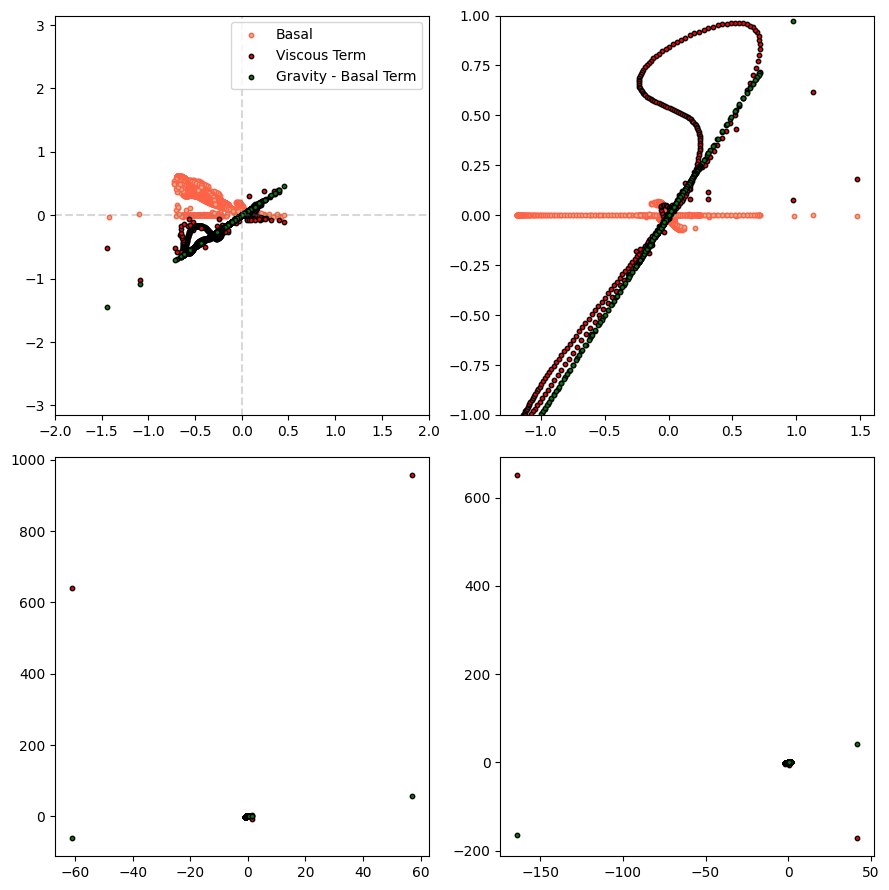

In [64]:
fig, axs = plt.subplots(len(idxgall), 2, figsize=(9, 9))

SC_SIZE = 10
ERR_SCALE = 1.0 
TERM_ALPHA = 0.2

for i in range(len(idxgall)):
    f, terms = eqn_evals[i]
    is_basal = terms.shape[1] >= 8
    print(f'SSA Eqn evaluation shape = {terms.shape}')
    print(f'Region {i} is {'grounded' if is_basal else 'floating'}')

    x_grav_term = terms[:, 2:3]
    x_visc_term = terms[:, 0:1] + terms[:, 1:2]
    x_basal_term = terms[:, 7:8] if is_basal else jnp.zeros_like(x_grav_term) 
    
    y_grav_term = terms[:, 5:6]
    y_visc_term = terms[:, 3:4] + terms[:, 4:5]
    y_basal_term = terms[:, 8:9] if is_basal else jnp.zeros_like(y_grav_term)

    print(x_visc_term.shape)
    print(x_basal_term.shape)
    
    grav_factor = 1.0 / gamma_mu if terms.shape[1]>8 else 1.0
    basal_factor = gamma_c / gamma_mu if terms.shape[1]>8 else 1.0
    print(f'grav_factor = {grav_factor}')
    print(f'basal_factor = {basal_factor}')

    x_grav_basal_term = grav_factor*x_grav_term + basal_factor*x_basal_term 
    y_grav_basal_term = grav_factor*y_grav_term + basal_factor*y_basal_term 
    
    # axs[i, 0].scatter(x_grav_basal_term, x_visc_term, s=1, c='blue', label='Viscous Term', alpha=TERM_ALPHA)
    
    # axs[i, 1].scatter(y_grav_basal_term, y_visc_term, s=1, c='blue', alpha=TERM_ALPHA)
    
    if terms.shape[1]>8:
        axs[i, 0].scatter(grav_factor*x_grav_term, basal_factor*x_basal_term, s=SC_SIZE, c='tan', label='Basal', ec='tomato')
        axs[i, 1].scatter(grav_factor*y_grav_term, basal_factor*y_basal_term, s=SC_SIZE, c='tan', label='Basal', ec='tomato')

    axs[i, 0].scatter(x_grav_basal_term, x_visc_term, label='Viscous Term', s=SC_SIZE, ec='k', c='r')
    axs[i, 1].scatter(y_grav_basal_term, y_visc_term, s=SC_SIZE, ec='k', c='r')
    
    axs[i, 1].scatter(y_grav_basal_term, y_grav_basal_term, label='Gravity - Basal Term', s=SC_SIZE, c='g', ec='k')
    axs[i, 0].scatter(x_grav_basal_term, x_grav_basal_term, label='Gravity - Basal Term', s=SC_SIZE, c='g', ec='k')
    
axs[0, 0].set_ylim([-3.15, 3.15])
axs[0, 0].set_xlim([-2, 2])
axs[0, 1].set_ylim([-1, 1])
axs[0,0].legend()
axs[0,0].hlines(0.0, xmin=-15, xmax=15, ls='--', color='gray', alpha=0.3)
axs[0,0].vlines(0.0, ymin=-15, ymax=15, ls='--', color='gray', alpha=0.3)
# axs[1, 0].set_ylim([-2, 2])
# axs[1, 1].set_ylim([-1, 1])
# axs[2, 0].set_ylim([-8, 8])
# axs[2, 1].set_ylim([-8, 8])
plt.tight_layout()

-1.0008123
0.9991877
-0.9762821
1.0237179


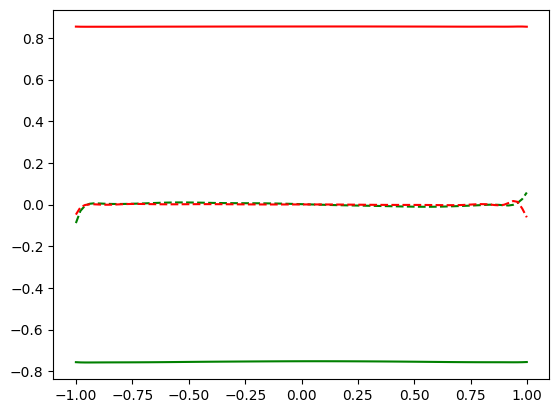

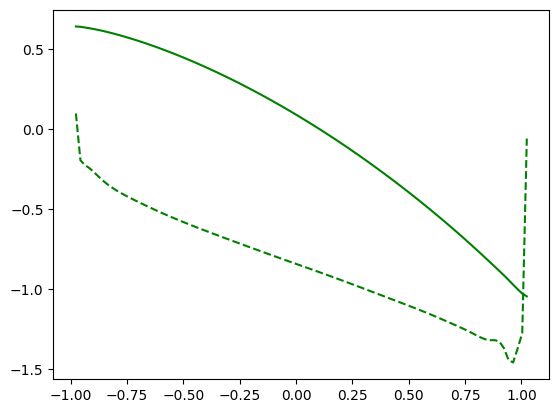

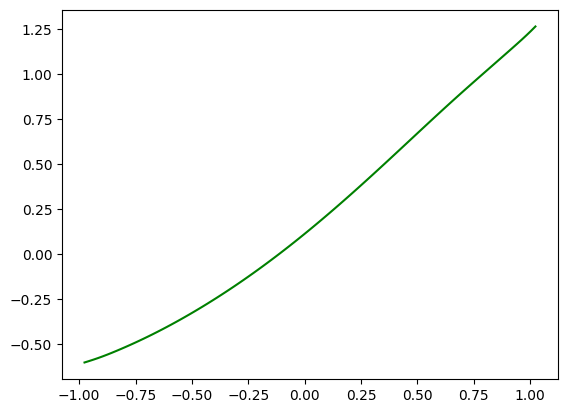

In [65]:
from jax import value_and_grad, vmap
x_norm = data_norm_region[0][0]
y_norm = data_norm_region[0][1]

print(jnp.min(y_norm))
print(jnp.max(y_norm))

print(jnp.min(x_norm))
print(jnp.max(x_norm))
y_slice = jnp.linspace(jnp.min(y_norm), jnp.max(y_norm), 100).reshape(100, 1)

x_slice = jnp.linspace(jnp.min(x_norm), jnp.max(x_norm), 100).reshape(100, 1)

def net_func_and_grad(x, y, region_idx:int, var_idx:int):
    f_func = lambda x, y: net(params, jnp.hstack((x, y)), region_idx)[var_idx]
    nn_func_grad = vmap(value_and_grad(f_func, argnums=[0, 1]), in_axes=(0,0) )
    f, grad_f= nn_func_grad(x, y)
    f_x, f_y = grad_f
    return f, f_x, f_y

h1, h_x, _ = net_func_and_grad(x_slice, jnp.zeros_like(x_slice), region_idx=0, var_idx=2)
h2, _, h_y = net_func_and_grad(0.8 * jnp.ones_like(y_slice), y_slice, region_idx=0, var_idx=2)

s2, s_x, _ = net_func_and_grad(x_slice, jnp.zeros_like(x_slice), region_idx=0, var_idx=3)
s1, _, s_y = net_func_and_grad(0.8 * jnp.ones_like(y_slice), y_slice, region_idx=0, var_idx=3)


u1, u_x, _ = net_func_and_grad(x_slice, jnp.zeros_like(x_slice), region_idx=0, var_idx=0)
u2, _, u_y = net_func_and_grad(0.8 * jnp.ones_like(y_slice), y_slice, region_idx=0, var_idx=0)

# s2, s_x, _ = net_func_and_grad(x_slice, jnp.zeros_like(x_slice), region_idx=0, var_idx=3)
# s1, _, s_y = net_func_and_grad(0.8 * jnp.ones_like(y_slice), y_slice, region_idx=0, var_idx=3)
# print(nn_trnsct.shape)
# print(grad_s.shape)

plt.plot(y_slice, s1, 'g-')
plt.plot(y_slice, s_y, 'g--')

plt.plot(y_slice, h2, 'r-')
plt.plot(y_slice, h_y, 'r--')

plt.figure()
plt.plot(x_slice, s2, 'g-')
plt.plot(x_slice, s_x, 'g--')

plt.figure()
plt.plot(x_slice, u1, 'g-')
# plt.plot(x_slice, u_x, 'g--')

In [66]:
from scipy.interpolate import griddata

def to_phys(x_n, z_n, dz_n, region_idx, var_idx):
    region_scale = scale[region_idx]
    d_mean = region_scale.data_mean 
    d_range = region_scale.data_range 
    x_mean = d_mean[0]
    x_range = d_range[0] 
    if var_idx == 3:
        z_mean = d_mean[var_idx + 2]
        z_range = d_range[var_idx + 2]
        print('s range = ', z_range)
        print('s mean = ', z_mean)
        z = z_n * z_range + z_mean
        dz = dz_n * (z_range / x_range)
    elif var_idx == 0:
        z_mean = d_mean[var_idx + 2]
        z_range = d_range[var_idx + 2]
        print('u range = ', z_range)
        z = (z_n*z_range + z_mean) * YTS
        dz = dz_n * (z_range / x_range) * YTS
    elif var_idx == 4: 
        y_range = d_range[1]
        u_range = d_range[2]
        v_range = d_range[3]
        s_range = d_range[5]
        h_mean = d_mean[4]
        l0 = jnp.minimum(x_range, y_range)
        u0 = jnp.maximum(u_range, v_range)

        _, _, mu0, c0, _, gamma_mu, gamma_c, _, _, _ = scale[region_idx][2]

        z = z_n * mu0 
        dz = dz_n
    elif var_idx == 5:
        _, _, mu0, c0, _, gamma_mu, gamma_c, _, _, _ = scale[region_idx][2]
        z = z_n * c0 
        dz = dz_n 
    else:
        raise NotImplementedError
    
    return (x_n * x_range) + x_mean, z, dz

def extract_raw_trnsct(x_trnsct, y_trnsct, region_idx, var_idx):
    x_raw_region = data_raw_region[region_idx][0].reshape(-1, 1)
    y_raw_region = data_raw_region[region_idx][1].reshape(-1, 1)
    if var_idx == 3:
        data_idx = 7
        x_raw_region = data_raw_region[region_idx][4].reshape(-1, 1)
        y_raw_region = data_raw_region[region_idx][5].reshape(-1, 1)
    elif var_idx == 0:
        data_idx = 2
    elif var_idx == 4:
        data_idx = 12
    elif var_idx == 5:
        data_idx = 13
    else:
        raise NotImplementedError
    var_raw_region = data_raw_region[region_idx][data_idx].reshape(-1, 1)
    print(f'[DEBUG]: var_raw_region shape = {var_raw_region.shape}')
    print(f'[DEBUG]: x_raw_region shape = {x_raw_region.shape}')
    X_data = jnp.hstack((x_raw_region, y_raw_region))
    print(f'[DEBUG]: x_raw_region shape = {X_data.shape}')
    
    return griddata(X_data, var_raw_region, jnp.hstack((x_trnsct, y_trnsct)))
# def interp_data_by_region(x_slice, region_idx, var_idx):

s range =  335.28976
s mean =  492.00006
s range =  69.921524
s mean =  62.17675
[DEBUG]: var_raw_region shape = (6226, 1)
[DEBUG]: x_raw_region shape = (6226, 1)
[DEBUG]: x_raw_region shape = (6226, 2)
[DEBUG]: var_raw_region shape = (9962, 1)
[DEBUG]: x_raw_region shape = (9962, 1)
[DEBUG]: x_raw_region shape = (9962, 2)


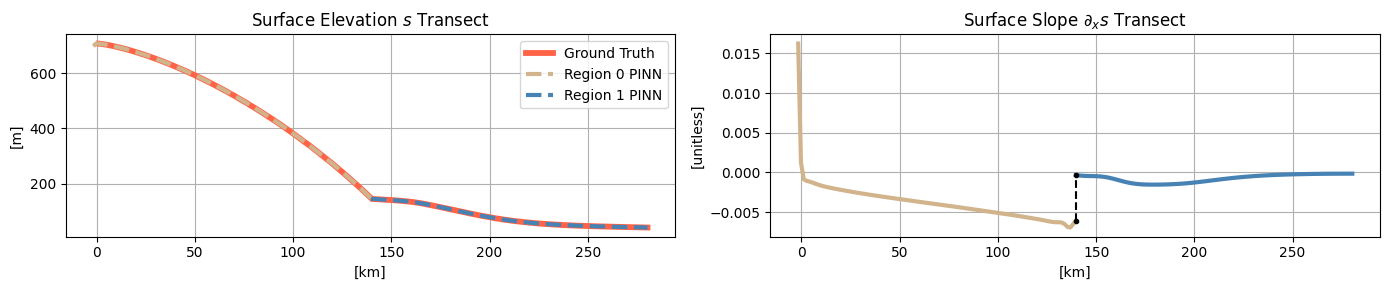

In [67]:
x_if = data_raw_region[0][10][0, 0]
x_if_1 = (x_if - scale[0].data_mean.x_mean) / scale[0].data_range.x_range
x_if_2 = (x_if - scale[1].data_mean.x_mean) / scale[1].data_range.x_range

x_slice_1 = jnp.linspace(-1.0, x_if_1, 100).reshape(100, 1)
x_slice_2 = jnp.linspace(x_if_2, 0.35, 100).reshape(100, 1)

LINE_WIDTH = 3
s1, s1_x, _ = net_func_and_grad(x_slice_1, jnp.zeros_like(x_slice_1), region_idx=0, var_idx=3)
s2, s2_x, _ = net_func_and_grad(x_slice_2, jnp.zeros_like(x_slice_2), region_idx=1, var_idx=3)

x1, s1, ds1 = to_phys(x_slice_1, s1, s1_x, region_idx=0, var_idx=3)
x2, s2, ds2 = to_phys(x_slice_2, s2, s2_x, region_idx=1, var_idx=3)

s1_data = extract_raw_trnsct(x1, jnp.zeros_like(x1), region_idx=0, var_idx=3)
s2_data = extract_raw_trnsct(x2, jnp.zeros_like(x2), region_idx=1, var_idx=3)

fig, axs = plt.subplots(1, 2, figsize=(14, 3))
axs[0].plot(x1/1e3, s1_data, c='tomato', lw=1.4*LINE_WIDTH, ls='-', label='Ground Truth')
axs[0].plot(x2/1e3, s2_data, c='tomato', lw=1.4*LINE_WIDTH, ls='-')
axs[0].plot(x1/1e3, s1, c='tan', lw=LINE_WIDTH, ls='--', label='Region 0 PINN')
axs[0].plot(x2/1e3, s2, c='steelblue', lw=LINE_WIDTH, ls='--', label='Region 1 PINN')
# axs[0].plot([x1[-1]/1e3, x2[0]/1e3], [s1[-1], s2[0]], 'k.--')
axs[0].set_title('Surface Elevation $s$ Transect')
axs[0].legend()
axs[0].set_ylabel('[m]')
axs[0].set_xlabel('[km]')
axs[0].grid()

axs[1].plot(x1/1e3, ds1, lw=LINE_WIDTH, c='tan')
axs[1].plot(x2/1e3, ds2, lw=LINE_WIDTH, c='steelblue')
axs[1].plot([x1[-1]/1e3, x2[0]/1e3], [ds1[-1], ds2[0]], 'k.--')
axs[1].set_title('Surface Slope $\\partial_x s$ Transect')
axs[1].set_ylabel('[unitless]')
axs[1].set_xlabel('[km]')
axs[1].grid()

# axs[0].set_xlim(220, 240)
# axs[0].set_ylim(0, 300)
# axs[1].plot([x1[-1], x2[0]], [ds1[-1], ds2[0]], 'k.--')
plt.tight_layout()

u range =  9.23316e-06
u range =  1.249009e-05
[DEBUG]: var_raw_region shape = (6226, 1)
[DEBUG]: x_raw_region shape = (6226, 1)
[DEBUG]: x_raw_region shape = (6226, 2)
[DEBUG]: var_raw_region shape = (9962, 1)
[DEBUG]: x_raw_region shape = (9962, 1)
[DEBUG]: x_raw_region shape = (9962, 2)


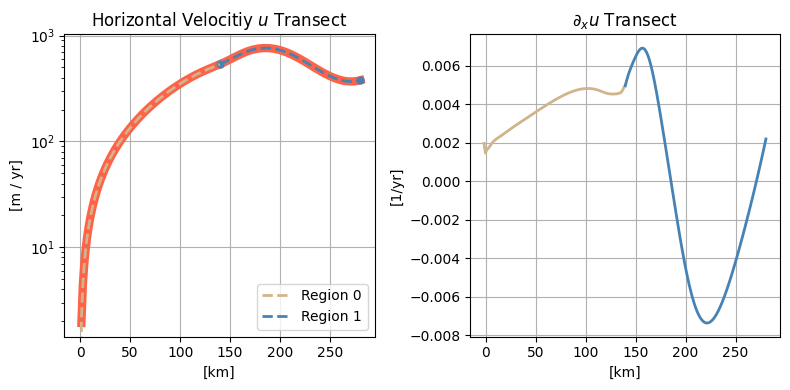

In [68]:
# x_slice_1 = jnp.linspace(-1.05, 1.7, 100).reshape(100, 1)
# x_slice_2 = jnp.linspace(-1.35, 1.0, 100).reshape(100, 1)
LINE_WIDTH = 2
u1, u1_x, _ = net_func_and_grad(x_slice_1, jnp.zeros_like(x_slice_1), region_idx=0, var_idx=0)
u2, u2_x, _ = net_func_and_grad(x_slice_2, jnp.zeros_like(x_slice_2), region_idx=1, var_idx=0)
x1, u1, du1 = to_phys(x_slice_1, u1, u1_x, 0, 0)
x2, u2, du2 = to_phys(x_slice_2, u2, u2_x, 1, 0)

u1_data = extract_raw_trnsct(x1, jnp.zeros_like(x1), region_idx=0, var_idx=0)
u2_data = extract_raw_trnsct(x2, jnp.zeros_like(x2), region_idx=1, var_idx=0)
u1_data *= YTS 
u2_data *= YTS 

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].semilogy(x1/1e3, u1_data, c='tomato', ls='-', lw=3*LINE_WIDTH)
axs[0].semilogy(x2/1e3, u2_data, c='tomato', ls='-', lw=3*LINE_WIDTH)
axs[0].plot([x1[0]/1e3, x1[-1]/1e3], [u1[0], u1[-1]], '.', markersize=10, c='tan')
axs[0].plot([x2[0]/1e3, x2[-1]/1e3], [u2[0], u2[-1]], '.', markersize=10, c='steelblue')
axs[0].semilogy(x1/1e3, u1, c='tan', ls='--', lw=LINE_WIDTH, label='Region 0')
axs[0].semilogy(x2/1e3, u2, c='steelblue', ls='--', lw=LINE_WIDTH, label='Region 1')
# axs[0].plot([x1[-1]/1e3, x2[0]/1e3], [u1[-1], u2[0]], 'k.--')
axs[0].set_title('Horizontal Velocitiy $u$ Transect')
axs[0].legend()
axs[0].set_ylabel('[m / yr]')
axs[0].set_xlabel('[km]')
axs[0].grid()

axs[1].plot(x1/1e3, du1, lw=LINE_WIDTH, c='tan')
axs[1].plot(x2/1e3, du2, lw=LINE_WIDTH, c='steelblue')
# axs[1].plot([x1[-1]/1e3, x2[0]/1e3], [du1[-1], du2[0]], 'k.--')
axs[1].set_title('$\\partial_x u$ Transect')
axs[1].set_ylabel('[1/yr]')
axs[1].set_xlabel('[km]')
axs[1].grid()
# axs[1].plot([x1[-1], x2[0]], [ds1[-1], ds2[0]], 'k.--')
plt.tight_layout()

[DEBUG]: var_raw_region shape = (6226, 1)
[DEBUG]: x_raw_region shape = (6226, 1)
[DEBUG]: x_raw_region shape = (6226, 2)
[DEBUG]: var_raw_region shape = (9962, 1)
[DEBUG]: x_raw_region shape = (9962, 1)
[DEBUG]: x_raw_region shape = (9962, 2)
[DEBUG]: var_raw_region shape = (6226, 1)
[DEBUG]: x_raw_region shape = (6226, 1)
[DEBUG]: x_raw_region shape = (6226, 2)
[DEBUG]: var_raw_region shape = (9962, 1)
[DEBUG]: x_raw_region shape = (9962, 1)
[DEBUG]: x_raw_region shape = (9962, 2)


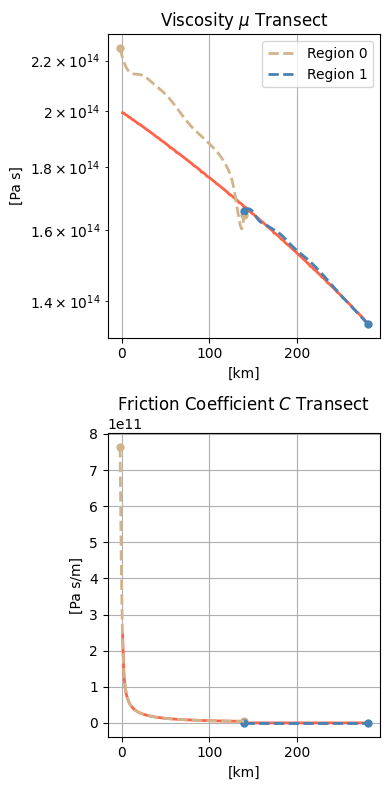

In [69]:
# x_slice_1 = jnp.linspace(-1.05, 1.7, 100).reshape(100, 1)
# x_slice_2 = jnp.linspace(-1.35, 1.0, 100).reshape(100, 1)
LINE_WIDTH = 2
mu1, mu1_x, _ = net_func_and_grad(x_slice_1, jnp.zeros_like(x_slice_1), region_idx=0, var_idx=4)
mu2, mu2_x, _ = net_func_and_grad(x_slice_2, jnp.zeros_like(x_slice_2), region_idx=1, var_idx=4)
x1, mu1, _ = to_phys(x_slice_1, mu1, u1_x, region_idx=0, var_idx=4)
x2, mu2, _ = to_phys(x_slice_2, mu2, u2_x, region_idx=1, var_idx=4)

mu1_data = extract_raw_trnsct(x1, jnp.zeros_like(x1), region_idx=0, var_idx=4)
mu2_data = extract_raw_trnsct(x2, jnp.zeros_like(x2), region_idx=1, var_idx=4)

C1, _, _ = net_func_and_grad(x_slice_1, jnp.zeros_like(x_slice_1), region_idx=0, var_idx=5)
C2, _, _ = net_func_and_grad(x_slice_2, jnp.zeros_like(x_slice_2), region_idx=1, var_idx=5)
x1, C1, _ = to_phys(x_slice_1, C1, u1_x, region_idx=0, var_idx=5)
x2, C2, _ = to_phys(x_slice_2, C2, u2_x, region_idx=1, var_idx=5)

C1_data = extract_raw_trnsct(x1, jnp.zeros_like(x1), region_idx=0, var_idx=5)
C2_data = extract_raw_trnsct(x2, jnp.zeros_like(x2), region_idx=1, var_idx=5)

fig, axs = plt.subplots(2, 1, figsize=(4, 8))
axs[0].semilogy(x1/1e3, mu1_data, c='tomato', ls='-', lw=LINE_WIDTH)
axs[0].semilogy(x2/1e3, mu2_data, c='tomato', ls='-', lw=LINE_WIDTH)
axs[0].plot([x1[0]/1e3, x1[-1]/1e3], [mu1[0], mu1[-1]], '.', markersize=10, c='tan')
axs[0].plot([x2[0]/1e3, x2[-1]/1e3], [mu2[0], mu2[-1]], '.', markersize=10, c='steelblue')
axs[0].semilogy(x1/1e3, mu1, c='tan', ls='--', lw=LINE_WIDTH, label='Region 0')
axs[0].semilogy(x2/1e3, mu2, c='steelblue', ls='--', lw=LINE_WIDTH, label='Region 1')
# axs[0].plot([x1[-1]/1e3, x2[0]/1e3], [u1[-1], u2[0]], 'k.--')
axs[0].set_title('Viscosity $\\mu$ Transect')
axs[0].legend()
axs[0].set_ylabel('[Pa s]')
axs[0].set_xlabel('[km]')
axs[0].grid()


axs[1].plot(x1/1e3, C1_data, c='tomato', ls='-', lw=LINE_WIDTH)
axs[1].plot(x2/1e3, C2_data, c='tomato', ls='-', lw=LINE_WIDTH)
axs[1].plot([x1[0]/1e3, x1[-1]/1e3], [C1[0], C1[-1]], '.', markersize=10, c='tan')
axs[1].plot([x2[0]/1e3, x2[-1]/1e3], [C2[0], C2[-1]], '.', markersize=10, c='steelblue')
axs[1].plot(x1/1e3, C1, c='tan', ls='--', lw=LINE_WIDTH, label='Region 0')
axs[1].plot(x2/1e3, C2, c='steelblue', ls='--', lw=LINE_WIDTH, label='Region 1')
axs[1].set_title('Friction Coefficient $C$ Transect')
axs[1].set_xlabel('[km]')
axs[1].grid()
axs[1].set_ylabel('[Pa s/m]')
# axs[1].plot(x1/1e3, du1, lw=LINE_WIDTH, c='tan')
# axs[1].plot(x2/1e3, du2, lw=LINE_WIDTH, c='steelblue')
# # axs[1].plot([x1[-1]/1e3, x2[0]/1e3], [du1[-1], du2[0]], 'k.--')
# axs[1].set_title('$\\partial_x u$ Transect')
# axs[1].set_ylabel('[1/yr]')
# axs[1].set_xlabel('[km]')
# axs[1].grid()
# axs[1].plot([x1[-1], x2[0]], [ds1[-1], ds2[0]], 'k.--')
plt.tight_layout()